In [1]:
# 1. 변수 선언 및 데이터 리스트 생성
E_GPa = 200.0                   # 강철의 탄성계수 (GPa)
E_MPa = E_GPa * 1000.0          # GPa를 MPa 단위로 변환 (1 GPa = 1000 MPa)

# 계산해야 할 변형률 데이터 리스트
strains = [0.0001, 0.0005, 0.001, 0.002]

print("=== 훅의 법칙 자동화 계산 결과 ===")

# 2. 반복문(for loop)을 이용한 자동화 계산
for strain in strains:
    # 훅의 법칙 (Stress = E * Strain)
    stress_MPa = E_MPa * strain

    # 3. 결과 출력 (소수점 1자리까지 표시)
    print(f"변형률: {strain:.4f} -> 발생하는 수직 응력: {stress_MPa:.1f} MPa")


=== 훅의 법칙 자동화 계산 결과 ===
변형률: 0.0001 -> 발생하는 수직 응력: 20.0 MPa
변형률: 0.0005 -> 발생하는 수직 응력: 100.0 MPa
변형률: 0.0010 -> 발생하는 수직 응력: 200.0 MPa
변형률: 0.0020 -> 발생하는 수직 응력: 400.0 MPa


<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3493/2027258575.py:45: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('Normal Stress ($\sigma$, MPa)', fontsize=12)


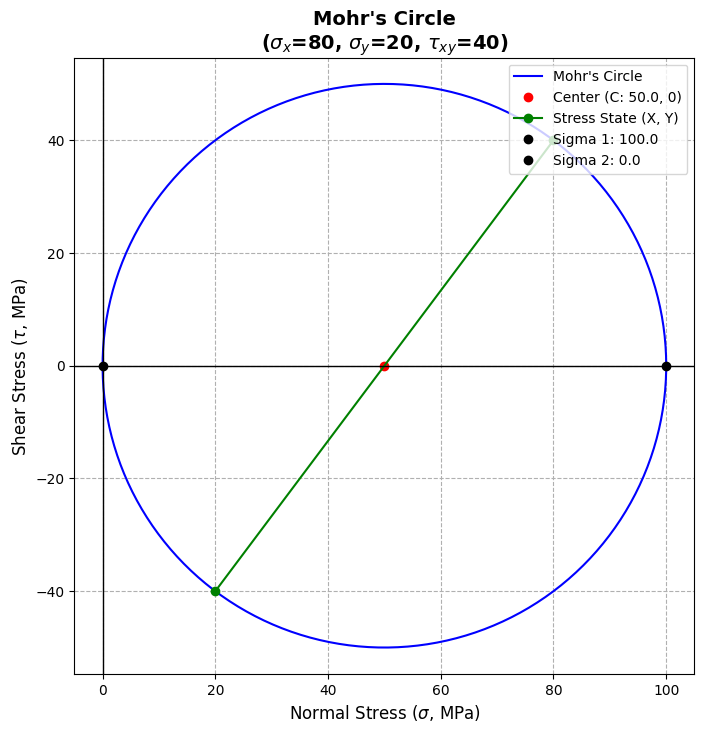

In [3]:
# --- 모어의 원 자동 시각화 스크립트 시작 ---
import matplotlib.pyplot as plt
import numpy as np

# 1. 문제의 평면 응력 상태 입력 (원하는 값으로 변경 가능)
sigma_x = 80   # MPa (가로 방향 수직 응력)
sigma_y = 20   # MPa (세로 방향 수직 응력)
tau_xy = 40    # MPa (전단 응력, 시계 방향 반대)

# 2. 모어의 원 계산 (numpy 활용)
# 원의 중심 (Center, 0) 계산
c = (sigma_x + sigma_y) / 2

# 원의 반지름 (Radius) 계산
r = np.sqrt(((sigma_x - sigma_y) / 2)**2 + tau_xy**2)

# 주요 응력 계산
sigma_1 = c + r    # 최대 주응력
sigma_2 = c - r    # 최소 주응력
tau_max = r        # 최대 전단 응력

# 3. 그래프 시각화 설정 (matplotlib 활용)
fig, ax = plt.figure(figsize=(8, 8)), plt.gca()

# 원 그리기 data 생성 (0도부터 360도까지)
theta = np.linspace(0, 2 * np.pi, 360)
x_circle = c + r * np.cos(theta)
y_circle = r * np.sin(theta)
plt.plot(x_circle, y_circle, color='blue', label="Mohr's Circle")

# 주요 지점 플로팅 (점 X, 점 Y, 중심 C, 주응력점)
plt.plot(c, 0, 'ro', label=f'Center (C: {c:.1f}, 0)')
plt.plot([sigma_x, sigma_y], [tau_xy, -tau_xy], 'g-o', label='Stress State (X, Y)')
plt.plot(sigma_1, 0, 'ko', label=f'Sigma 1: {sigma_1:.1f}')
plt.plot(sigma_2, 0, 'ko', label=f'Sigma 2: {sigma_2:.1f}')

# 축 설정 (이 부분의 'axis equal'이 완벽한 원을 그리는 핵심 비법입니다)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--')
plt.axis('equal') # X축과 Y축의 비율을 동일하게 설정 (핵심!)

# 타이틀 및 축 라벨 설정
plt.title(f'Mohr\'s Circle\n($\\sigma_x$={sigma_x}, $\\sigma_y$={sigma_y}, $\\tau_{{xy}}$={tau_xy})', fontsize=14, fontweight='bold')
plt.xlabel('Normal Stress ($\sigma$, MPa)', fontsize=12)
plt.ylabel('Shear Stress ($\\tau$, MPa)', fontsize=12)
plt.legend(loc='upper right')

plt.show()
# --- 모어의 원 자동 시각화 스크립트 끝 ---
